   Year  Total Population
4  2018             65630
3  2019             69744
1  2020             74467
0  2021             89711
2  2022             95042
5  2023             99844
6  2024            104923


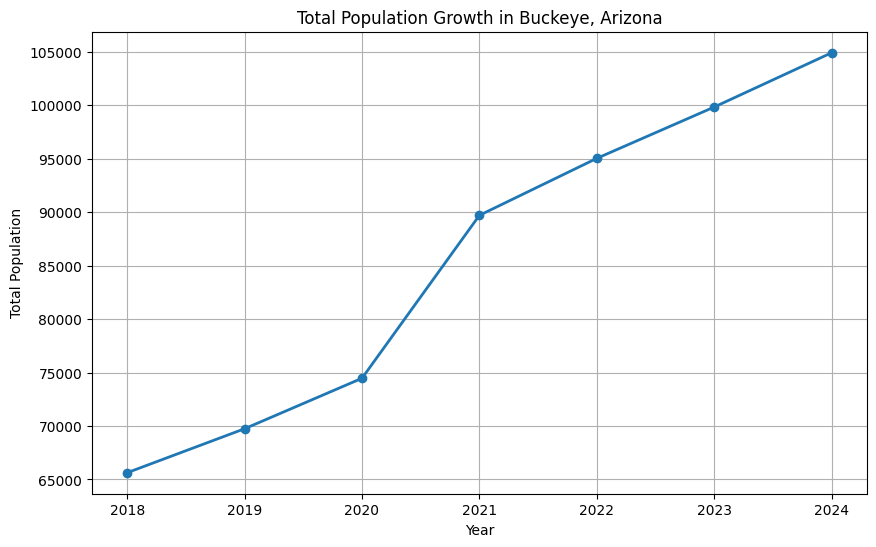

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import re

files = glob.glob("ACSDP5Y*.xlsx")

data = []

for file in files:
    year = int(re.search(r"ACSDP5Y(\d{4})", file).group(1))

    # The useful table starts on row 2 in Excel, so use header=1
    df = pd.read_excel(file, sheet_name="Data", header=1)

    # Find Total population row
    pop_row = df[df["Label"].astype(str).str.strip() == "Total population"]

    if pop_row.empty:
        print(f"Could not find Total population in {file}")
        continue

    # Estimate column has the population
    population = pop_row["Estimate"].values[0]

    # Clean commas and convert to number
    population = int(str(population).replace(",", ""))

    data.append([year, population])

# Create dataframe
pop_df = pd.DataFrame(data, columns=["Year", "Total Population"])
pop_df = pop_df.sort_values("Year")

print(pop_df)

# Line chart
plt.figure(figsize=(10, 6))
plt.plot(pop_df["Year"], pop_df["Total Population"], marker="o", linewidth=2)

plt.title("Total Population Growth in Buckeye, Arizona")
plt.xlabel("Year")
plt.ylabel("Total Population")
plt.grid(True)

plt.show()

2025: 114,002
2026: 121,096
2027: 128,191
2028: 135,286
2029: 142,381


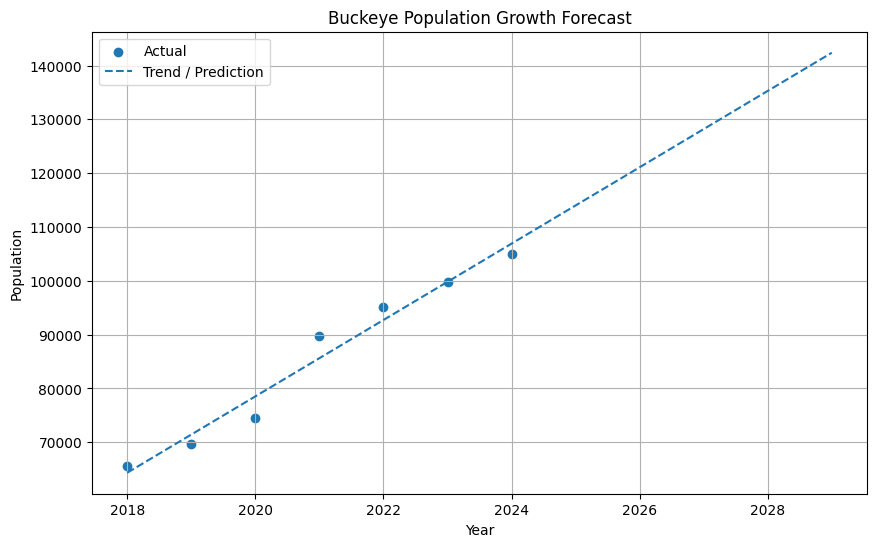

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Your data
years = np.array([2018, 2019, 2020, 2021, 2022, 2023, 2024]).reshape(-1, 1)
population = np.array([65630, 69744, 74467, 89711, 95042, 99844, 104923])

# Train model
model = LinearRegression()
model.fit(years, population)

# Future years
future_years = np.array([2025, 2026, 2027, 2028, 2029]).reshape(-1, 1)
future_pred = model.predict(future_years)

# Combine for plotting
all_years = np.vstack((years, future_years))
all_pred = model.predict(all_years)

# Print predictions
for y, p in zip(future_years.flatten(), future_pred):
    print(f"{y}: {int(p):,}")

# Plot
plt.figure(figsize=(10,6))

# Actual data
plt.scatter(years, population, label="Actual")

# Regression line + prediction
plt.plot(all_years, all_pred, linestyle='--', label="Trend / Prediction")

plt.xlabel("Year")
plt.ylabel("Population")
plt.title("Buckeye Population Growth Forecast")
plt.legend()
plt.grid()

plt.show()

In [20]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Actual historical data
years = np.array([2018, 2019, 2020, 2021, 2022, 2023, 2024]).reshape(-1, 1)
population = np.array([65630, 69744, 74467, 89711, 95042, 99844, 104923])

# Fit model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(years, population)

# Predictions on training data
pred = model.predict(years)

# --- Metrics ---
mae = mean_absolute_error(population, pred)
rmse = np.sqrt(mean_squared_error(population, pred))
r2 = r2_score(population, pred)

# MAPE (percentage error)
mape = np.mean(np.abs((population - pred) / population)) * 100

print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MAE: 2,210.00
RMSE: 2,593.06
R²: 0.9677
MAPE: 2.68%


In [21]:
# Your predictions
pred_2025 = 114002
pred_2026 = 121096

# Actual values
actual_2025 = 119500
actual_2026 = 124600

# Compute % error
error_2025 = abs(pred_2025 - actual_2025) / actual_2025 * 100
error_2026 = abs(pred_2026 - actual_2026) / actual_2026 * 100

print(f"2025 Error: {error_2025:.2f}%")
print(f"2026 Error: {error_2026:.2f}%")

2025 Error: 4.60%
2026 Error: 2.81%


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error

X_train, X_test, y_train, y_test = train_test_split(years, population, test_size=0.3, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_mape = mean_absolute_percentage_error(y_train, train_pred) * 100
test_mape = mean_absolute_percentage_error(y_test, test_pred) * 100

print(f"Train MAPE: {train_mape:.2f}%")
print(f"Test MAPE: {test_mape:.2f}%")

Train MAPE: 3.59%
Test MAPE: 1.50%


                Label  Estimate
5       Under 5 years      8142
6        5 to 9 years      7585
7      10 to 14 years      8248
8      15 to 19 years      6690
9      20 to 24 years      4839
10     25 to 34 years     15609
11     35 to 44 years     16515
12     45 to 54 years     12351
13     55 to 59 years      4782
14     60 to 64 years      5656
15     65 to 74 years     10162
16     75 to 84 years      3636
17  85 years and over       708


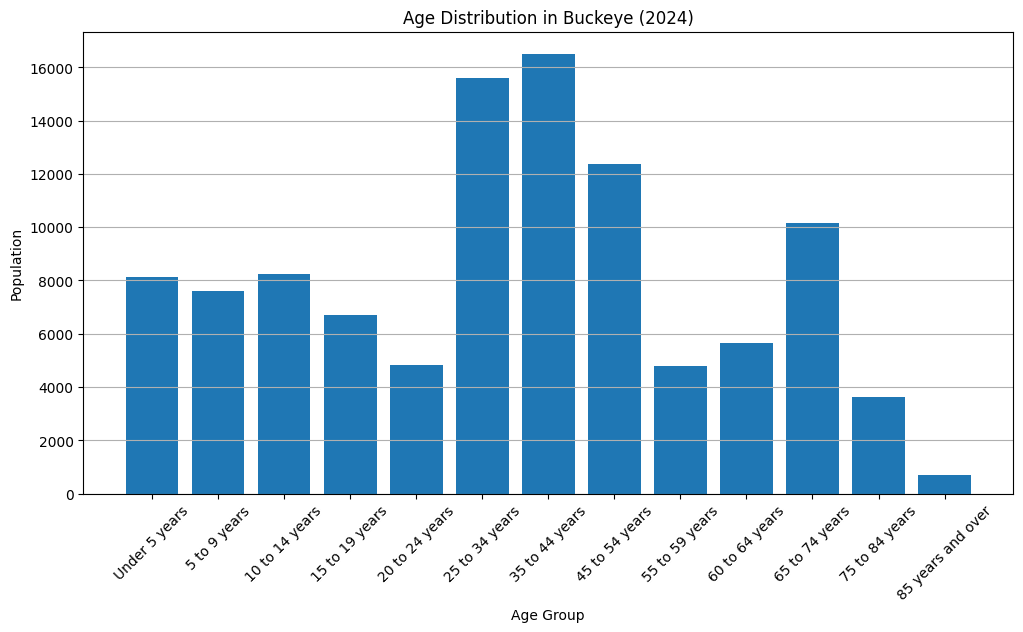

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load 2024 file
file = "ACSDP5Y2024.DP05-2026-04-30T191120.xlsx"

# Read data (header row is row 2)
df = pd.read_excel(file, sheet_name="Data", header=1)

# Clean label column
df["Label"] = df["Label"].astype(str).str.strip()

# Define age groups (based on ACS format)
age_keywords = [
    "Under 5 years", "5 to 9 years", "10 to 14 years",
    "15 to 19 years", "20 to 24 years", "25 to 34 years",
    "35 to 44 years", "45 to 54 years",
    "55 to 59 years", "60 to 64 years",
    "65 to 74 years", "75 to 84 years", "85 years and over"
]

# Filter age rows
age_df = df[df["Label"].isin(age_keywords)].copy()

# Clean population values
age_df["Estimate"] = age_df["Estimate"].astype(str).str.replace(",", "")
age_df["Estimate"] = age_df["Estimate"].astype(int)

# Sort in correct order
age_df["Label"] = pd.Categorical(age_df["Label"], categories=age_keywords, ordered=True)
age_df = age_df.sort_values("Label")

print(age_df[["Label", "Estimate"]])

# Plot
plt.figure(figsize=(12,6))
plt.bar(age_df["Label"], age_df["Estimate"])

plt.title("Age Distribution in Buckeye (2024)")
plt.xlabel("Age Group")
plt.ylabel("Population")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

                                             Industry  Percent
79  Agriculture, forestry, fishing and hunting, an...      0.7
80                                       Construction      9.6
81                                      Manufacturing      7.4
82                                    Wholesale trade      2.7
83                                       Retail trade     12.8
84      Transportation and warehousing, and utilities      9.2
85                                        Information      1.3
86  Finance and insurance, and real estate and ren...      8.9
87  Professional, scientific, and management, and ...     10.2
88  Educational services, and health care and soci...     19.4
89  Arts, entertainment, and recreation, and accom...      6.8
91                              Public administration      6.3


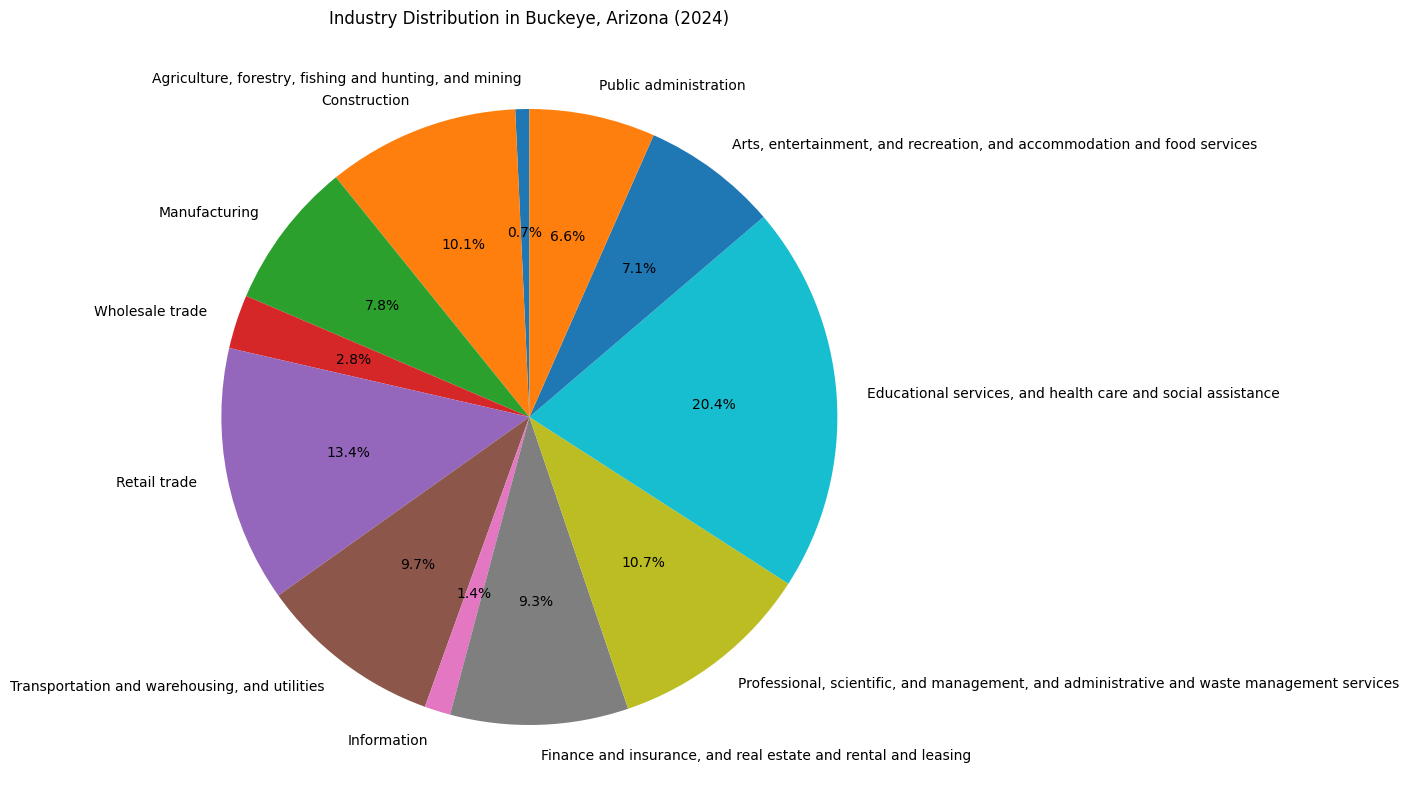

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

file = "ACSST5Y2024.S0501-2026-04-30T193846.xlsx"

# Read without assuming column names
df = pd.read_excel(file, sheet_name="Data", header=None)

# Clean first column
df[0] = df[0].astype(str).str.strip()

# Find INDUSTRY section
industry_start = df[df[0].str.upper() == "INDUSTRY"].index[0]

# Industry categories in ACS table
industry_labels = [
    "Agriculture, forestry, fishing and hunting, and mining",
    "Construction",
    "Manufacturing",
    "Wholesale trade",
    "Retail trade",
    "Transportation and warehousing, and utilities",
    "Information",
    "Finance and insurance, and real estate and rental and leasing",
    "Professional, scientific, and management, and administrative and waste management services",
    "Educational services, and health care and social assistance",
    "Arts, entertainment, and recreation, and accommodation and food services",
    "Other services, except public administration",
    "Public administration"
]

# Take rows after INDUSTRY
industry_df = df.iloc[industry_start + 1:].copy()

# Keep only industry rows
industry_df = industry_df[industry_df[0].isin(industry_labels)]

# Column 1 = first Estimate/Percent column shown in your file
industry_df = industry_df[[0, 1]]
industry_df.columns = ["Industry", "Percent"]

# Clean percent values
industry_df["Percent"] = (
    industry_df["Percent"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.strip()
)

industry_df["Percent"] = pd.to_numeric(industry_df["Percent"], errors="coerce")

# Drop missing values
industry_df = industry_df.dropna()

print(industry_df)

# Pie chart
plt.figure(figsize=(10, 10))
plt.pie(
    industry_df["Percent"],
    labels=industry_df["Industry"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Industry Distribution in Buckeye, Arizona (2024)")
plt.show()

                                           Occupation  Percent
73  Management, business, science, and arts occupa...     39.6
74                                Service occupations     13.7
75                       Sales and office occupations     22.1
76  Natural resources, construction, and maintenan...      9.7
77  Production, transportation, and material movin...     14.9


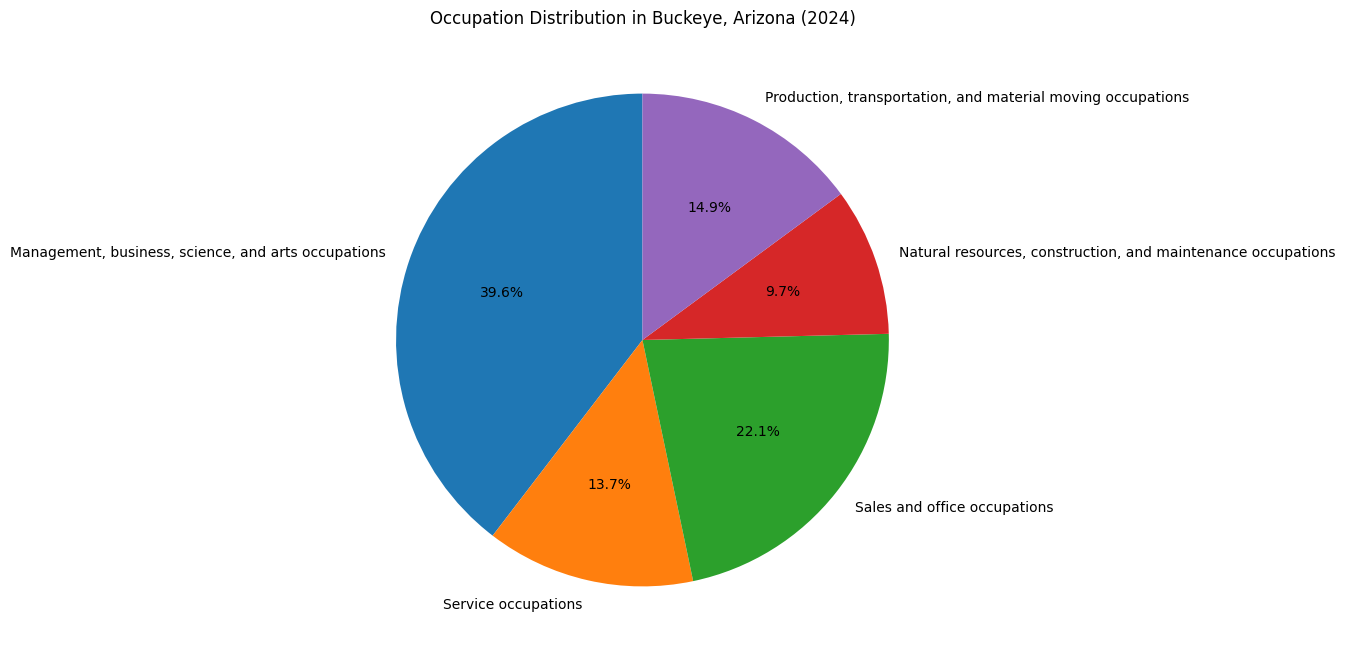

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

file = "ACSST5Y2024.S0501-2026-04-30T193846.xlsx"

df = pd.read_excel(file, sheet_name="Data", header=None)
df[0] = df[0].astype(str).str.strip()

occupation_labels = [
    "Management, business, science, and arts occupations",
    "Service occupations",
    "Sales and office occupations",
    "Natural resources, construction, and maintenance occupations",
    "Production, transportation, and material moving occupations"
]

occ_df = df[df[0].isin(occupation_labels)].copy()

occ_df = occ_df[[0, 1]]
occ_df.columns = ["Occupation", "Percent"]

occ_df["Percent"] = (
    occ_df["Percent"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.strip()
)

occ_df["Percent"] = pd.to_numeric(occ_df["Percent"], errors="coerce")

print(occ_df)

plt.figure(figsize=(8, 8))
plt.pie(
    occ_df["Percent"],
    labels=occ_df["Occupation"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Occupation Distribution in Buckeye, Arizona (2024)")
plt.show()

                           Status  Percent
35                  Never married     30.9
36  Now married, except separated     54.8
37          Divorced or separated     10.5
38                        Widowed      3.8


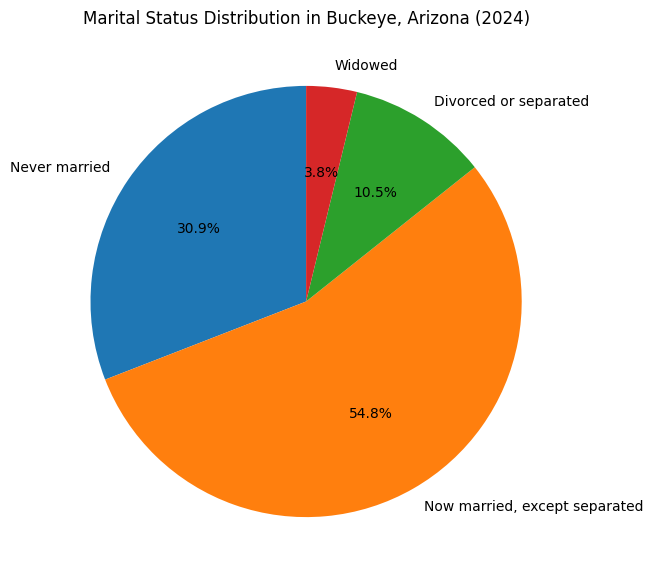

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

file = "ACSST5Y2024.S0501-2026-04-30T193846.xlsx"

# Read raw data
df = pd.read_excel(file, sheet_name="Data", header=None)

# Clean first column
df[0] = df[0].astype(str).str.strip()

# Marital status labels
marital_labels = [
    "Never married",
    "Now married, except separated",
    "Divorced or separated",
    "Widowed"
]

# Filter rows
marital_df = df[df[0].isin(marital_labels)].copy()

# Select columns
marital_df = marital_df[[0, 1]]
marital_df.columns = ["Status", "Percent"]

# Clean percent values
marital_df["Percent"] = (
    marital_df["Percent"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.strip()
)

marital_df["Percent"] = pd.to_numeric(marital_df["Percent"], errors="coerce")

print(marital_df)

# Plot pie chart
plt.figure(figsize=(7,7))
plt.pie(
    marital_df["Percent"],
    labels=marital_df["Status"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Marital Status Distribution in Buckeye, Arizona (2024)")
plt.show()

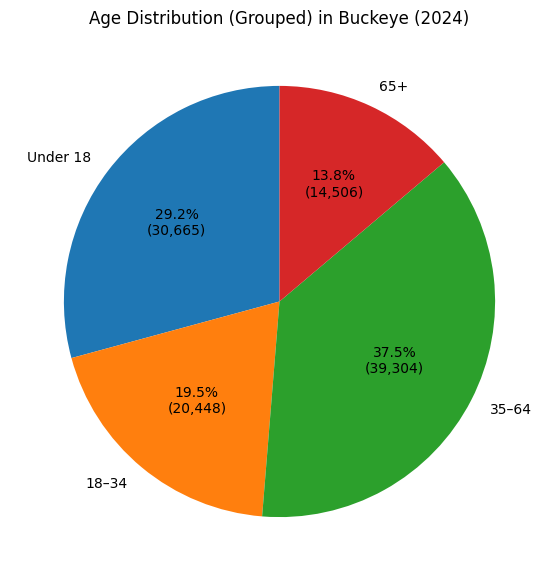

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

file = "ACSDP5Y2024.DP05-2026-04-30T191120.xlsx"

df = pd.read_excel(file, sheet_name="Data", header=1)

df["Label"] = df["Label"].astype(str).str.strip()
df["Estimate"] = df["Estimate"].astype(str).str.replace(",", "", regex=False)
df["Estimate"] = pd.to_numeric(df["Estimate"], errors="coerce")

age_groups = [
    "Under 5 years", "5 to 9 years", "10 to 14 years",
    "15 to 19 years", "20 to 24 years", "25 to 34 years",
    "35 to 44 years", "45 to 54 years", "55 to 59 years",
    "60 to 64 years", "65 to 74 years", "75 to 84 years",
    "85 years and over"
]

age_df = df[df["Label"].isin(age_groups)].copy()

# Grouping
bins = {
    "Under 18": ["Under 5 years", "5 to 9 years", "10 to 14 years", "15 to 19 years"],
    "18–34": ["20 to 24 years", "25 to 34 years"],
    "35–64": ["35 to 44 years", "45 to 54 years", "55 to 59 years", "60 to 64 years"],
    "65+": ["65 to 74 years", "75 to 84 years", "85 years and over"]
}

grouped = {}

for group, labels in bins.items():
    grouped[group] = age_df[age_df["Label"].isin(labels)]["Estimate"].sum()

group_df = pd.DataFrame(list(grouped.items()), columns=["Group", "Population"])

# Custom label function
def autopct_format(values):
    def inner(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n({val:,})"
    return inner

# Plot
plt.figure(figsize=(7,7))
plt.pie(
    group_df["Population"],
    labels=group_df["Group"],
    autopct=autopct_format(group_df["Population"]),
    startangle=90
)

plt.title("Age Distribution (Grouped) in Buckeye (2024)")
plt.show()